# Import the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import pathlib 
import os
# import scimap as sm
from utils.delaunay_graph import delaunay_adata_internal, delaunay_adata
from utils.cluster_stability import cluster_stability_calculate
from utils.celltype_enrichment_niche import nhood_enrichment
import anndata as ad

# Paths

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

# Color palette

In [3]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

# Loading the required data

In [67]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata.h5ad"))

# Creating delaunay graphs for the ROIs

In [68]:
adata = delaunay_adata(adata, 
                       coords_key="spatial", 
                       phenotype="cell_category", 
                       image_id="patient_exp", 
                       label="spatial_count_delaunay")

## Get the confusion matrix of the neighbors

In [69]:
adata.uns["spatial_prop_delaunay"] = adata.uns["spatial_count_delaunay"].div(adata.uns["spatial_count_delaunay"].sum(axis=1), axis=0)

In [70]:
adata.uns["spatial_prop_delaunay"]

neighbour_phenotype,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,MDSCs,Mast cells,NFC,NK cells,PCs,Treg T cells,Tumor cells,Epithelial cells
378930,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66114,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66113,0.111111,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.222222,0.0,0.0,0.0,0.666667,0.0
66112,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66111,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.142857,0.285714,0.000000,0.000000,0.0,0.142857,0.0,0.0,0.0,0.428571,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420571,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420572,0.000000,0.0,0.4,0.6,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
420573,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420564,0.000000,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [ ]:
best_k, best_score, results_df = cluster_stability_calculate(
    adata,
    uns_key="spatial_prop_delaunay",
    k_min=8,
    k_max=18,
    n_repeats=10,        
    sample_size=50000,      
    random_state=196979
)

k=8 | mean ARI=0.9608
k=9 | mean ARI=0.9175
k=10 | mean ARI=0.9442
k=11 | mean ARI=0.9646
k=12 | mean ARI=0.9654
k=13 | mean ARI=0.8720
k=14 | mean ARI=0.7272
k=15 | mean ARI=0.8711
k=16 | mean ARI=0.9021
k=17 | mean ARI=0.8265
k=18 | mean ARI=0.8638


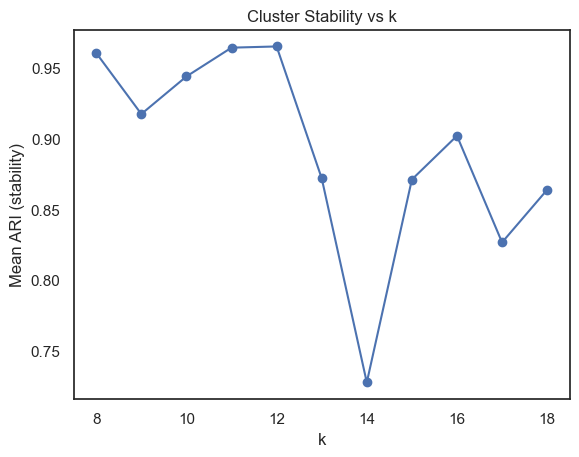

In [72]:
#showcase cluster stability analysis results
plt.figure()
plt.plot(results_df.index, results_df["mean_ARI"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean ARI (stability)")
plt.title("Cluster Stability vs k")
plt.show()

In [73]:
#save the results of cluster stability analysis
results_df.to_csv(os.path.join(data_dir, "cluster_stability_results.csv"), index=True)

## k = 12

In [74]:
adata = sm.tl.spatial_cluster(adata, 
                              df_name='spatial_prop_delaunay', 
                              method='kmeans', 
                              k=12, 
                              label='neigh_kmeans_count', 
                              random_state=196979)

Kmeans clustering


In [75]:
sm.pl.stacked_barplot(adata, 
                      x_axis='neigh_kmeans_count', 
                      y_axis='cell_category', 
                      plot_tool='plotly', 
                      color_discrete_map = full_palette)

In [76]:
#mix clustters 4 and 9 since they are similar in composition and define the clusters as follows:
cluster_to_name = {
    0: "Lymphatic_immune",
    1: "Tumor_bulk",
    2: "Tumor_NFC",
    3: "Stromal_fibroblasts",
    4: "Myeloid_granulocytic",
    5: "Epithelial_adjacent",
    6: "Vascular/Endothelial",
    7: "Lymphoid_B",
    8: "Lymphoid_enriched",
    9: "Tumor_myeloid",
    10: "Lymphoid_T",
    11:"Stromal_NFC"
}
#make neigh_kmeans integers first
adata.obs["neigh_kmeans_count"] = adata.obs["neigh_kmeans_count"].astype(int)
adata.obs["neighborhood"] = adata.obs["neigh_kmeans_count"].map(cluster_to_name)

In [77]:
nhood_enrichment(
    adata,
    group_key="cell_category",
    label_key="neighborhood",
    log=True,
    pvalues=True, 
)

100%|██████████| 200/200 [00:11<00:00, 17.08it/s]


In [78]:
adata.uns.keys()

odict_keys(['spatial_count_delaunay', 'spatial_prop_delaunay', 'neighborhood_cell_category_enrichment'])

In [79]:
enr = adata.uns["neighborhood_cell_category_enrichment"]["enrichment"]
pvalues = adata.uns["neighborhood_cell_category_enrichment"]["pvalue"]

## Save the enrichment and the pvalues

In [80]:
enr.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment.csv"), index=True)
pvalues.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"), index=True)

# Finally save the anndata with the neighborhoods

In [81]:
#save anndata
adata.write_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

## save the niches as niches_df for R

In [82]:
niches_df = adata.obs[["patient_ID", "patient_exp", "cell_category", "Cell Center X", "Cell Center Y", "survival_time_months", "neighborhood"]].copy()
niches_df.to_csv(os.path.join(data_dir, "niches_df.csv"), index=False)

In [47]:
adata_neighborhoods = sc.read_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

In [48]:
#keep in adata run == 141 and 145
adata_neighborhoods_subset = adata_neighborhoods[adata_neighborhoods.obs["run"].isin([141, 145])].copy()
#markers vector
markers = adata_neighborhoods_subset.var_names
#keep markers where not all values are NA
markers = [
    marker for marker in markers
    if not np.isnan(adata_neighborhoods_subset[:, marker].X.toarray()).any()
]

In [49]:
adata_neighborhoods_subset = adata_neighborhoods_subset[:, markers].copy()

adata_neighborhoods_subset.X = np.arcsinh(adata_neighborhoods_subset.X)

In [50]:
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

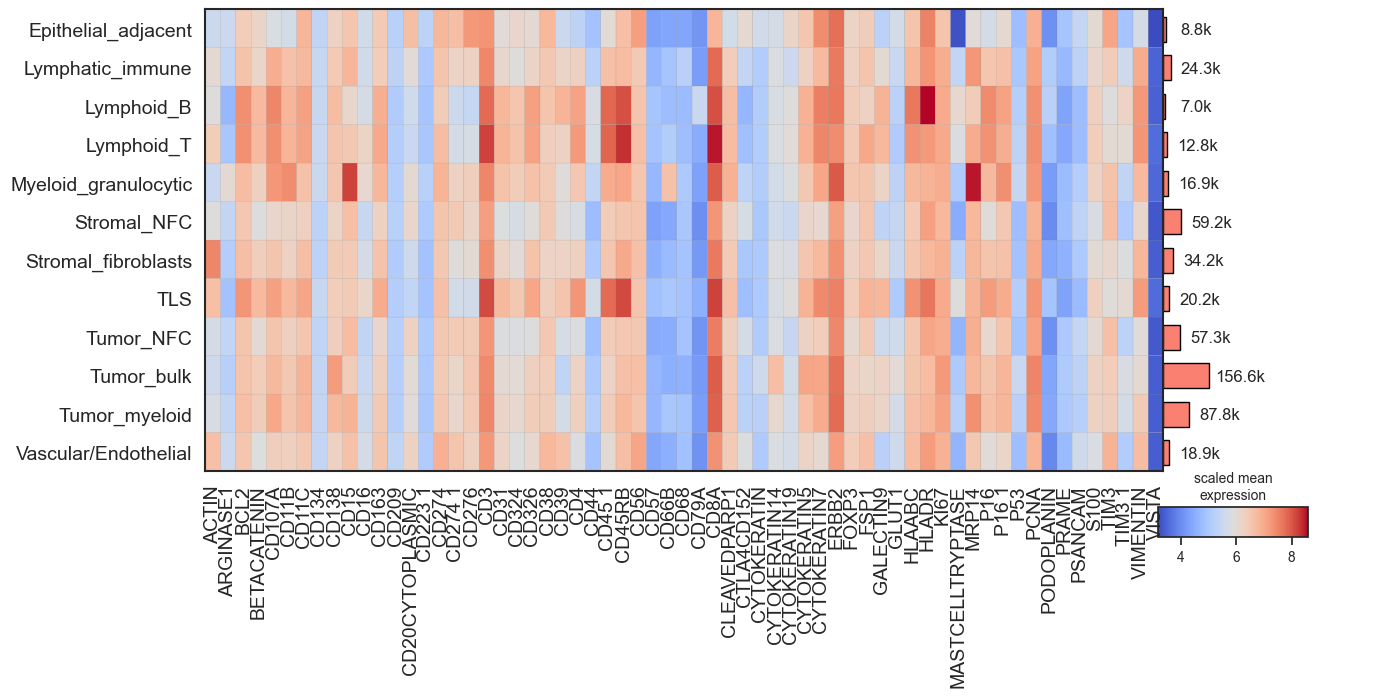

In [36]:
plot = sc.pl.matrixplot(adata_neighborhoods_subset, markers, groupby='neighborhood', 
                            cmap='coolwarm', 
                            use_raw=False, 
                            figsize=(15, 6), 
                            return_fig=True)
plot.add_totals()
axes = plot.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 12, current_pos[1]+4))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax.set_position([0.76, 0, 0.1, 0.05])
fig = axes['mainplot_ax'].figure
# fig.savefig(os.path.join(results_dir, 'stacked_violin.png'), 
#             dpi=300, 
#             bbox_inches='tight')

## EXPERIMENTING

In [4]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

In [5]:
#markers to keep 
adata_141 = adata[adata.obs["run"] == 141].copy()
#get the var_names that have no NA values
markers_141 = [
    marker for marker in adata_141.var_names
    if not np.isnan(adata_141[:, marker].X.toarray()).any()
]
#same for 145
adata_145 = adata[adata.obs["run"] == 145].copy()
markers_145 = [
    marker for marker in adata_145.var_names
    if not np.isnan(adata_145[:, marker].X.toarray()).any()
]
#take the intersection of the two marker lists
markers = list(set(markers_141) & set(markers_145))


In [6]:
#make anndata_unified
adata_unified = adata[:, markers].copy()
#arcsinh-transform your data
adata_unified.layers["arcsinh"] = np.arcsinh(adata_unified.X)


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/3891719571.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["neighborhood", "patient_exp"])["KI67"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/3891719571.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_df.groupby("neighborhood")["KI67"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/3891719571.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=

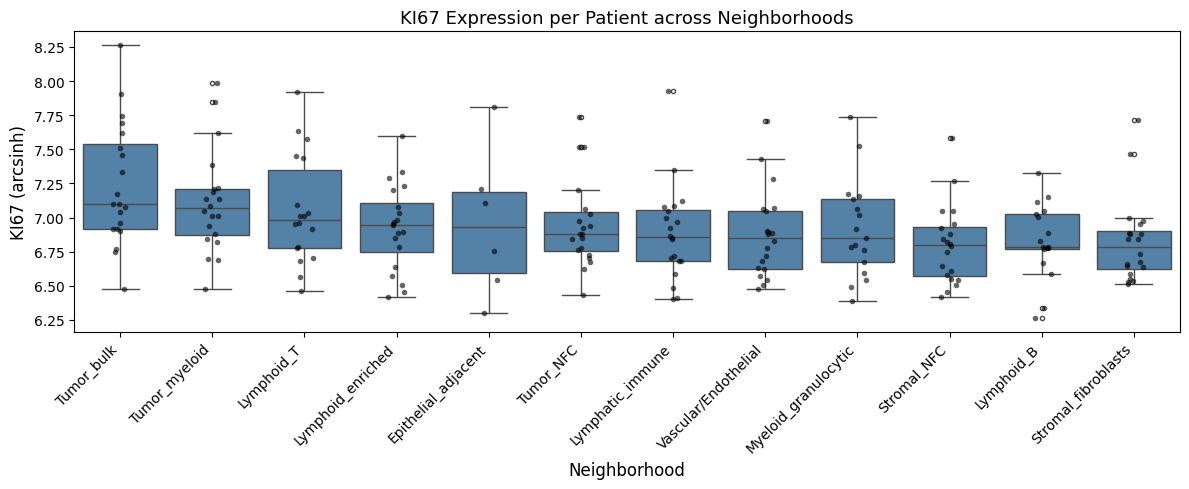

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract KI67 arcsinh values
ki67_idx = list(adata_unified.var_names).index("KI67")
ki67_values = adata_unified.layers["arcsinh"][:, ki67_idx]

# Build a dataframe with per-cell values + metadata
df = pd.DataFrame({
    "KI67": np.array(ki67_values).flatten(),
    "neighborhood": adata_unified.obs["neighborhood"].values,
    "patient_exp": adata_unified.obs["patient_exp"].values,
})

# Aggregate to patient level: median KI67 per patient per neighborhood
patient_df = (
    df.groupby(["neighborhood", "patient_exp"])["KI67"]
    .median()
    .reset_index()
)

# Compute neighborhood-level median (of patient medians) for ordering
neighborhood_order = (
    patient_df.groupby("neighborhood")["KI67"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=patient_df,
    x="neighborhood",
    y="KI67",
    order=neighborhood_order,
    color="steelblue",
    fliersize=3,
    ax=ax,
)
sns.stripplot(
    data=patient_df,
    x="neighborhood",
    y="KI67",
    order=neighborhood_order,
    color="black",
    alpha=0.6,
    size=4,
    jitter=True,
    ax=ax,
)

ax.set_xlabel("Neighborhood", fontsize=12)
ax.set_ylabel("KI67 (arcsinh)", fontsize=12)
ax.set_title("KI67 Expression per Patient across Neighborhoods", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cell_category", "patient_exp"])["GLUT1"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_df.groupby("cell_category")["GLUT1"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

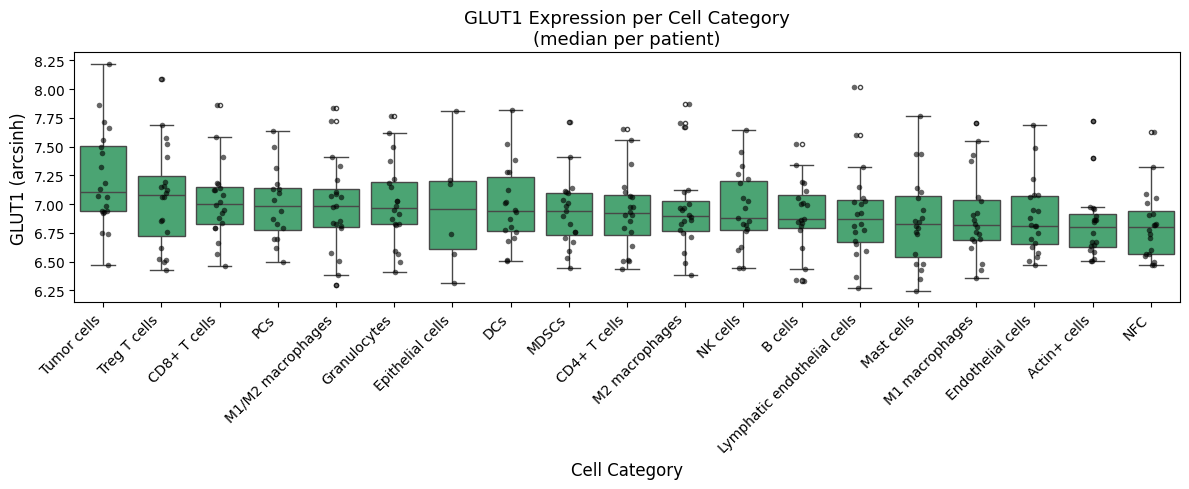

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract GLUT1 arcsinh values
glut1_idx = list(adata_unified.var_names).index("KI67")
glut1_values = np.array(adata_unified.layers["arcsinh"][:, glut1_idx]).flatten()

# Build dataframe
df = pd.DataFrame({
    "GLUT1": glut1_values,
    "cell_category": adata_unified.obs["cell_category"].values,
    "patient_exp": adata_unified.obs["patient_exp"].values,
})

# Aggregate to patient level per cell category
patient_df = (
    df.groupby(["cell_category", "patient_exp"])["GLUT1"]
    .median()
    .reset_index()
)

# Sort cell categories by median of patient medians (descending)
category_order = (
    patient_df.groupby("cell_category")["GLUT1"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=patient_df,
    x="cell_category",
    y="GLUT1",
    order=category_order,
    color="mediumseagreen",
    fliersize=3,
    ax=ax,
)
sns.stripplot(
    data=patient_df,
    x="cell_category",
    y="GLUT1",
    order=category_order,
    color="black",
    alpha=0.6,
    size=4,
    jitter=True,
    ax=ax,
)

ax.set_xlabel("Cell Category", fontsize=12)
ax.set_ylabel("GLUT1 (arcsinh)", fontsize=12)
ax.set_title("GLUT1 Expression per Cell Category\n(median per patient)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:67: FutureWa

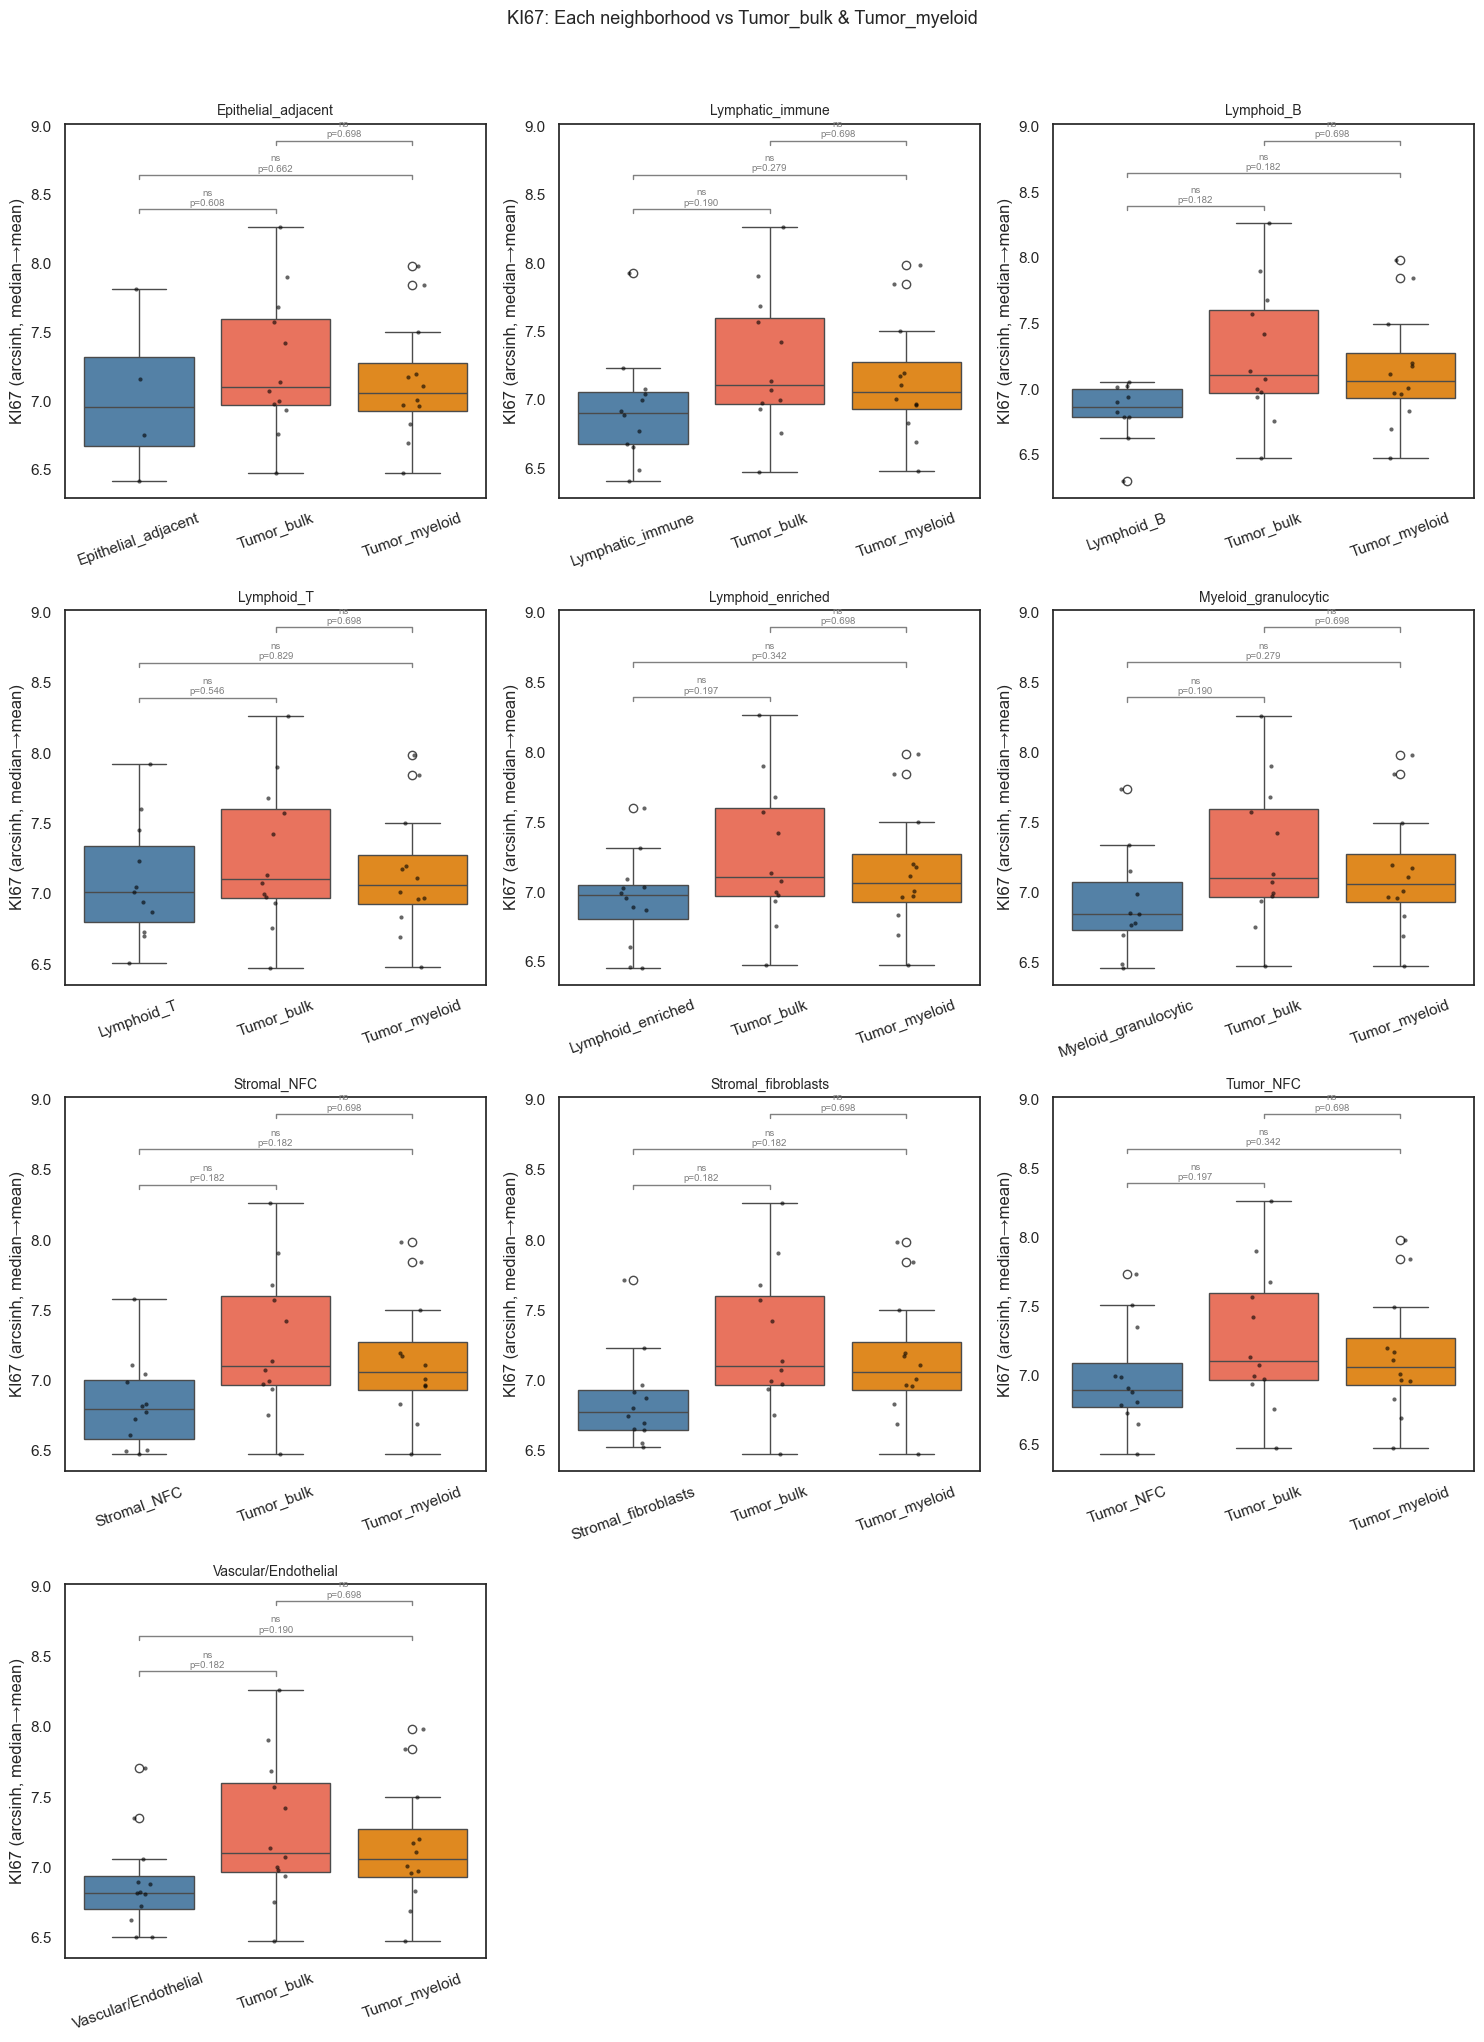

In [32]:
# --- Build aggregated df for KI67 only ---
ki67_idx = adata_unified.var_names.get_loc("KI67")

df = adata_unified.obs[["patient_ID", "patient_exp", "neighborhood"]].copy()
df["KI67"] = adata_unified.layers["arcsinh"][:, ki67_idx]

# Step 1: median per ROI
df_roi = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["KI67"].median().reset_index()

# Step 2: mean across ROIs per patient
df_agg = df_roi.groupby(["patient_ID", "neighborhood"])["KI67"].mean().reset_index()

# --- Define comparisons ---
reference_neighborhoods = ["Tumor_bulk", "Tumor_myeloid"]
all_neighborhoods = df_agg["neighborhood"].unique().tolist()
other_neighborhoods = [n for n in all_neighborhoods if n not in reference_neighborhoods]

pairs = [(ref, other) for ref in reference_neighborhoods for other in other_neighborhoods]
pairs.append(("Tumor_bulk", "Tumor_myeloid"))

# --- Run Mann-Whitney U tests with FDR correction ---
results = []
for n1, n2 in pairs:
    g1 = df_agg[df_agg["neighborhood"] == n1]["KI67"].dropna()
    g2 = df_agg[df_agg["neighborhood"] == n2]["KI67"].dropna()
    if len(g1) < 3 or len(g2) < 3:
        continue
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    results.append({"n1": n1, "n2": n2, "p_value": p})

results_df = pd.DataFrame(results)
_, p_adj, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_adj"] = p_adj
results_df["significant"] = results_df["p_adj"] < 0.05

# --- Helper functions ---
def get_pval(df, a, b):
    row = df[((df["n1"] == a) & (df["n2"] == b)) | ((df["n1"] == b) & (df["n2"] == a))]
    return row["p_adj"].values[0] if len(row) else np.nan

def pval_label(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def draw_bracket(ax, x1, x2, y, p):
    label = pval_label(p)
    color = "black" if label != "ns" else "gray"
    ax.plot([x1, x1, x2, x2], [y, y + 0.03, y + 0.03, y], lw=1, color=color)
    ax.text((x1 + x2) / 2, y + 0.04, f"{label}\np={p:.3f}",
            ha="center", va="bottom", fontsize=7, color=color)

# --- Plot ---
ncols = 3
nrows = int(np.ceil(len(other_neighborhoods) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
axes = axes.flatten()

for i, neighborhood in enumerate(other_neighborhoods):
    ax = axes[i]
    order = [neighborhood, "Tumor_bulk", "Tumor_myeloid"]
    plot_df = df_agg[df_agg["neighborhood"].isin(order)].copy()
    pal = {neighborhood: "steelblue", "Tumor_bulk": "tomato", "Tumor_myeloid": "darkorange"}

    sns.boxplot(data=plot_df, x="neighborhood", y="KI67", order=order, ax=ax, palette=pal)
    sns.stripplot(data=plot_df, x="neighborhood", y="KI67", order=order, ax=ax,
                  color="black", size=3, alpha=0.6)

    y_base = plot_df["KI67"].max() + 0.1
    bracket_gap = 0.25

    draw_bracket(ax, 0, 1, y_base, get_pval(results_df, neighborhood, "Tumor_bulk"))
    draw_bracket(ax, 0, 2, y_base + bracket_gap, get_pval(results_df, neighborhood, "Tumor_myeloid"))
    draw_bracket(ax, 1, 2, y_base + bracket_gap * 2, get_pval(results_df, "Tumor_bulk", "Tumor_myeloid"))

    ax.set_title(neighborhood, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("KI67 (arcsinh, median→mean)")
    ax.tick_params(axis="x", rotation=20)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KI67: Each neighborhood vs Tumor_bulk & Tumor_myeloid", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
test = ["GLUT1", "KI67", "P53", "GALECTIN9"]

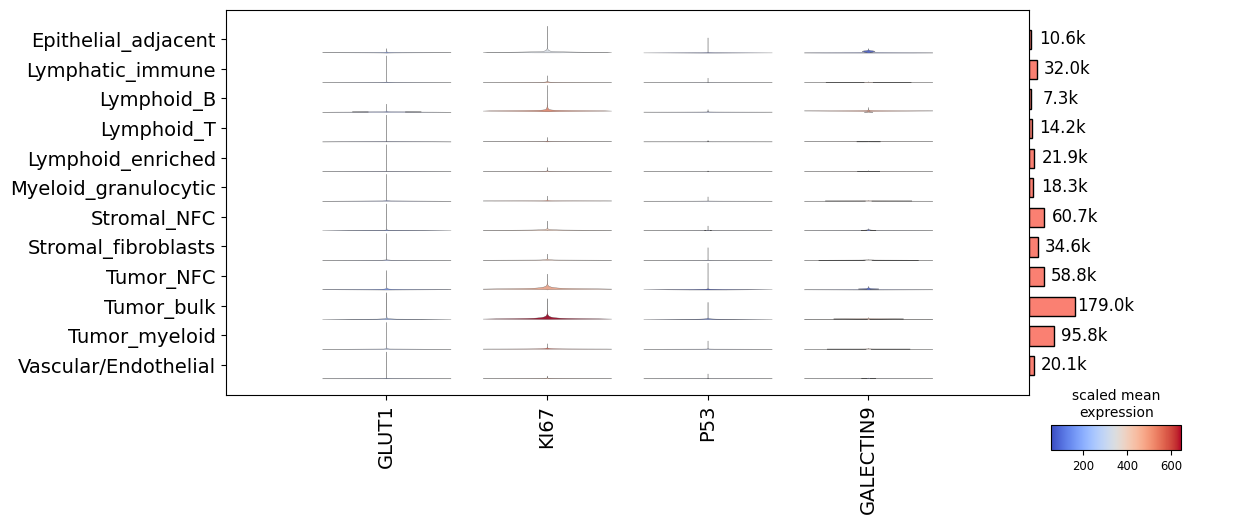

In [ ]:
plot = sc.pl.stacked_violin(adata_unified, test, groupby='neighborhood', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(13, 5), return_fig=True)
plot.add_totals()
axes = plot.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 12, current_pos[1]+4))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax.set_position([0.76, 0, 0.1, 0.05])
fig = axes['mainplot_ax'].figure
# fig.savefig(os.path.join("/Users/jawadalaaedeen/Desktop/", 'stacked_violin.pdf'), 
#             dpi=300, 
#             bbox_inches='tight')

cell_category  M2 macrophages     MDSCs  Granulocytes
patient_ID                                           
NUT_1                0.743151  0.253425      0.003425
NUT_2                0.216216  0.168168      0.615616
NUT_4                0.040446  0.330544      0.629010
NUT_5                0.317943  0.329486      0.352571
NUT_6                0.861239  0.000000      0.138761
NUT_7                0.624722  0.364143      0.011136
NUT_8                0.191304  0.356522      0.452174
NUT_9                0.109327  0.469421      0.421251
NUT_12               0.923077  0.060440      0.016484
NUT_13               0.826790  0.166282      0.006928
NUT_14               0.577236  0.317073      0.105691
NUT_15               0.057778  0.135556      0.806667
NUT_16               0.178746  0.563211      0.258044


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2088085524.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



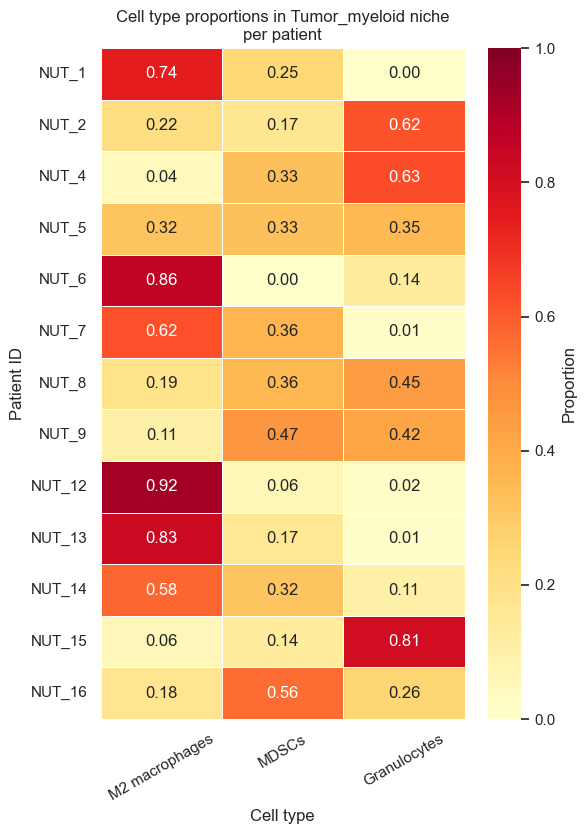

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Filter to Tumor_myeloid neighborhood ---
mask = adata_unified.obs["neighborhood"] == "Tumor_myeloid"
df = adata_unified.obs[mask][["patient_ID", "cell_category"]].copy()

# --- Filter to cell types of interest ---
cells_of_interest = ["M2 macrophages", "MDSCs", "Granulocytes"]
df = df[df["cell_category"].isin(cells_of_interest)]

# --- Compute proportions per patient ---
# Count each cell type per patient
counts = df.groupby(["patient_ID", "cell_category"]).size().unstack(fill_value=0)

# Normalize to proportions (row-wise)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Ensure all cell types are present even if missing for some patients
for cell in cells_of_interest:
    if cell not in proportions.columns:
        proportions[cell] = 0.0
proportions = proportions[cells_of_interest]

print(proportions)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(6, len(proportions) * 0.5 + 2))

sns.heatmap(
    proportions,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion"}
)

ax.set_title("Cell type proportions in Tumor_myeloid niche\nper patient", fontsize=12)
ax.set_xlabel("Cell type")
ax.set_ylabel("Patient ID")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [49]:
cd15_per_celltype

cell_category
Actin+ cells                  NaN
B cells                       NaN
CD4+ T cells                  NaN
CD8+ T cells                  NaN
DCs                           NaN
Endothelial cells             NaN
Granulocytes                  NaN
Lymphatic endothelial cells   NaN
M1 macrophages                NaN
M1/M2 macrophages             NaN
M2 macrophages                NaN
MDSCs                         NaN
Mast cells                    NaN
NFC                           NaN
NK cells                      NaN
Treg T cells                  NaN
Tumor cells                   NaN
Name: CD15, dtype: float64

In [50]:
mask = adata_unified.obs["patient_ID"] == "NUT_7"
adata_sub = adata_unified[mask]

cd15_idx = adata_unified.var_names.get_loc("CD15")

# Check what we're getting
print("CD15 index:", cd15_idx)
print("Layer slice sample:", adata_sub.layers["arcsinh"][:5, cd15_idx])
print("Any NaN?", np.isnan(adata_sub.layers["arcsinh"][:, cd15_idx]).any())
print("All NaN?", np.isnan(adata_sub.layers["arcsinh"][:, cd15_idx]).all())
print("NUT_7 cell count:", mask.sum())
print("Unique cell_category in NUT_7:", adata_sub.obs["cell_category"].unique())

CD15 index: 56
Layer slice sample: [6.03994557 6.10922309 6.44790027 6.23722706 6.5529416 ]
Any NaN? False
All NaN? False
NUT_7 cell count: 64784
Unique cell_category in NUT_7: ['Lymphatic endothelial cells', 'Tumor cells', 'Endothelial cells', 'M1/M2 macrophages', 'M2 macrophages', ..., 'Granulocytes', 'Treg T cells', 'Mast cells', 'CD4+ T cells', 'NK cells']
Length: 17
Categories (17, object): ['Actin+ cells', 'B cells', 'CD4+ T cells', 'CD8+ T cells', ..., 'NFC', 'NK cells', 'Treg T cells', 'Tumor cells']


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/100117243.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/100117243.py:27: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



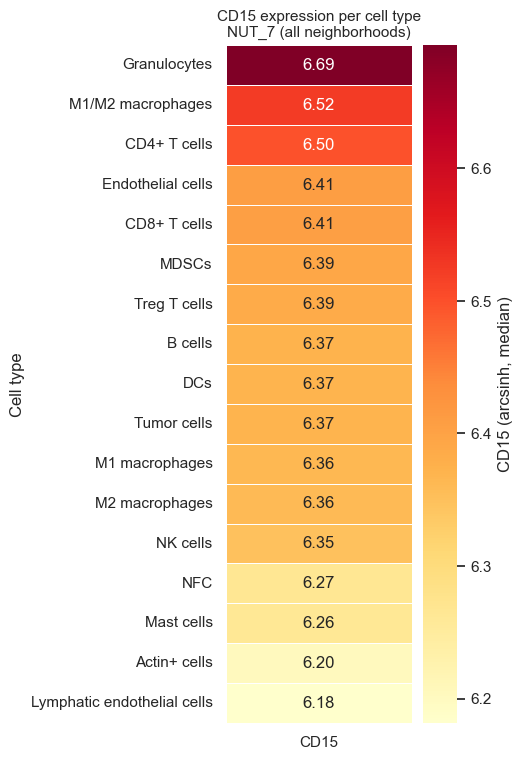

In [63]:
mask = adata_unified.obs["patient_ID"] == "NUT_7"
adata_sub = adata_unified[mask]
#turn into a df
df = adata_sub.to_df()
df["cell_category"] = adata_sub.obs["cell_category"]
df = df[["cell_category", "CD15"]]
cd15_per_celltype = df.groupby("cell_category")["CD15"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(3, len(cd15_per_celltype) * 0.4 + 2))

sns.heatmap(
    cd15_per_celltype.to_frame(),
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "CD15 (arcsinh, median)"}
)

ax.set_title("CD15 expression per cell type\nNUT_7 (all neighborhoods)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Cell type")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

True True
High Granulocytic     7
High M2 Macrophage    6
Name: count, dtype: int64
   patient_ID  MDSC_proportion               group
0       NUT_1         0.011659  High M2 Macrophage
1       NUT_2         0.008566   High Granulocytic
2       NUT_4         0.028020   High Granulocytic
3       NUT_5         0.018111   High Granulocytic
4       NUT_6         0.000000  High M2 Macrophage
5       NUT_7         0.019079  High M2 Macrophage
6       NUT_8         0.027841   High Granulocytic
7       NUT_9         0.071243   High Granulocytic
8      NUT_12         0.001008  High M2 Macrophage
9      NUT_13         0.004126  High M2 Macrophage
10     NUT_14         0.002757  High M2 Macrophage
11     NUT_15         0.004678   High Granulocytic
12     NUT_16         0.085433   High Granulocytic

Mann-Whitney U p-value: 0.0221


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




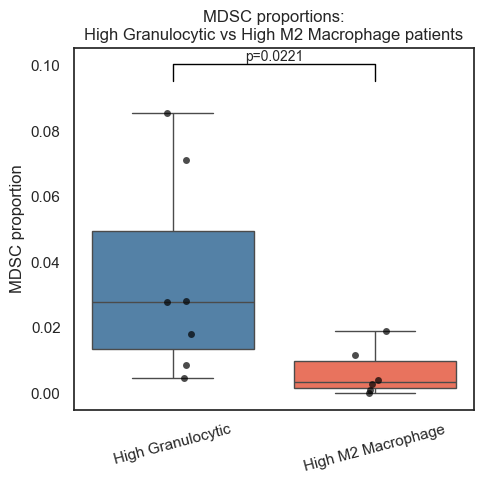

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# --- Get cell counts per patient ---
df = adata_unified.obs[["patient_ID", "patient_exp", "cell_category"]].copy()
df["cell_category"] = df["cell_category"].astype(str)

# Count per patient_exp (ROI) then mean per patient to handle multiple ROIs
counts_roi = df.groupby(["patient_ID", "patient_exp", "cell_category"]).size().unstack(fill_value=0)
counts_patient = counts_roi.groupby("patient_ID").mean()

# Compute proportions
proportions = counts_patient.div(counts_patient.sum(axis=1), axis=0)

# --- Classify patients ---
# Check columns exist
print("Granulocytes" in proportions.columns, "M2 macrophages" in proportions.columns)

granulocyte_prop = proportions["Granulocytes"]
m2_prop = proportions["M2 macrophages"]
mdsc_prop = proportions["MDSCs"]

# Patients with more granulocytes than M2 macrophages and vice versa
patient_group = pd.Series(index=proportions.index, dtype=str)
patient_group[granulocyte_prop > m2_prop] = "High Granulocytic"
patient_group[m2_prop > granulocyte_prop] = "High M2 Macrophage"

print(patient_group.value_counts())

# --- Build comparison df ---
compare_df = pd.DataFrame({
    "patient_ID": proportions.index,
    "MDSC_proportion": mdsc_prop.values,
    "group": patient_group.values
}).dropna()

print(compare_df)

# --- Stats ---
g1 = compare_df[compare_df["group"] == "High Granulocytic"]["MDSC_proportion"]
g2 = compare_df[compare_df["group"] == "High M2 Macrophage"]["MDSC_proportion"]
stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
print(f"\nMann-Whitney U p-value: {p:.4f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(5, 5))

palette = {"High Granulocytic": "steelblue", "High M2 Macrophage": "tomato"}
order = ["High Granulocytic", "High M2 Macrophage"]

sns.boxplot(data=compare_df, x="group", y="MDSC_proportion", order=order, palette=palette, ax=ax)
sns.stripplot(data=compare_df, x="group", y="MDSC_proportion", order=order,
              color="black", size=5, alpha=0.7, ax=ax)

# Bracket
y_max = compare_df["MDSC_proportion"].max() + 0.01
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.005, y_max + 0.005, y_max], lw=1, color="black")
ax.text(0.5, y_max + 0.006, f"p={p:.4f}", ha="center", fontsize=10)

ax.set_title("MDSC proportions:\nHigh Granulocytic vs High M2 Macrophage patients")
ax.set_xlabel("")
ax.set_ylabel("MDSC proportion")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()